<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/PetroVision_U-Net_Baseline_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PetroVision — U-Net Baseline Training

**Experiment ID:** CV-UNET-001  
**Task:** Binary semantic segmentation  
**Dataset:** LADOS  
**Target classes:** Oil, Emulsion, Sheen  
**Input:** RGB images, 256×256  
**Model:** Lightweight U-Net  
**Loss:** BCE + Dice  
**Purpose:** Train a stronger baseline using GPU

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Project Setup

In [ ]:
!git clone https://github.com/krithi-ks/PetroVision.git
%cd PetroVision

Cloning into 'PetroVision'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 112 (delta 25), reused 55 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 58.22 KiB | 578.00 KiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/PetroVision


In [ ]:
from pathlib import Path

print("Project root:", Path.cwd())
print("\nProject files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)

Project root: /content/PetroVision

Project files:
 - .git
 - .gitignore
 - README.md
 - app
 - data
 - docs
 - notebooks
 - references
 - reports
 - requirements.txt
 - results
 - src


## 2. Dataset Setup

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

print("ZIP exists:", ZIP_PATH.exists())
print("ZIP path:", ZIP_PATH)

ZIP exists: True
ZIP path: /content/drive/MyDrive/PetroVision/datasets/PetroVision.v1i.png-mask-semantic.zip


## 3. Dataset Verification

In [ ]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

EXTRACT_DIR = Path("/content/PetroVision/data/lados")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)

Dataset extracted to: /content/PetroVision/data/lados


In [ ]:
for split in ["train", "valid", "test"]:
    split_dir = EXTRACT_DIR / split

    images = [
        p for p in split_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        and not p.name.endswith("_mask.png")
    ]

    masks = list(split_dir.glob("*_mask.png"))

    print(
        f"{split:5s} | "
        f"images: {len(images):4d} | "
        f"masks: {len(masks):4d}"
    )

train | images: 2370 | masks: 2370
valid | images:  675 | masks:  675
test  | images:  343 | masks:  343


## 4. Environment Setup

In [ ]:
!pip install -q Pillow numpy pandas matplotlib opencv-python scikit-learn PyYAML tqdm

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


## 5. PetroVision Model Code

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/PetroVision")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.vision.lados_dataset import LADOSDataset
from src.vision.unet import UNet
from src.vision.segmentation_loss import BCEDiceLoss

print("PetroVision modules loaded successfully.")

PetroVision modules loaded successfully.


In [ ]:
DATASET_ROOT = PROJECT_ROOT / "data" / "lados"

train_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="train",
    image_size=(256, 256),
    augment=True,
)

valid_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="valid",
    image_size=(256, 256),
    augment=False,
)

test_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="test",
    image_size=(256, 256),
    augment=False,
)

print("Train:", len(train_dataset))
print("Validation:", len(valid_dataset))
print("Test:", len(test_dataset))

Train: 2370
Validation: 675
Test: 343


## 6. Training Configuration

In [ ]:
from torch.utils.data import DataLoader
import torch

# Reproducibility
SEED = 42
torch.manual_seed(SEED)

# Experiment
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-3

# Device
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Experiment: CV-UNET-001")
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Experiment: CV-UNET-001
Image size: (256, 256)
Batch size: 16
Epochs: 20
Learning rate: 0.001
Device: cuda
GPU: Tesla T4


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Training batches: 149
Validation batches: 43
Test batches: 22


## 7. Model and Optimizer

In [ ]:
model = UNet(
    in_channels=3,
    out_channels=1,
).to(DEVICE)

criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

print("Trainable parameters:", sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
))

print("Model, loss function, and optimizer ready.")

Trainable parameters: 1942577
Model, loss function, and optimizer ready.


## 8. Training

In [ ]:
from pathlib import Path
import torch

CHECKPOINT_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_DIR / "unet_baseline_best.pt"

train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()
    running_train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, masks in valid_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(valid_loader)

    # Store losses for visualization
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # Save best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss

        torch.save(
            model.state_dict(),
            "/content/PetroVision/models/unet_baseline_best.pt"
        )

        best_marker = " ← best"
    else:
        best_marker = ""

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Validation Loss: {epoch_val_loss:.6f}"
        f"{best_marker}"
    )

print(f"\nBest validation loss: {best_val_loss:.6f}")
print(f"Best model: {BEST_MODEL_PATH}")

Epoch 01/20 | Train Loss: 0.523054 | Validation Loss: 0.499403 ← best
Epoch 02/20 | Train Loss: 0.505032 | Validation Loss: 0.486043 ← best
Epoch 03/20 | Train Loss: 0.489186 | Validation Loss: 0.485385 ← best
Epoch 04/20 | Train Loss: 0.482357 | Validation Loss: 0.480259 ← best
Epoch 05/20 | Train Loss: 0.478776 | Validation Loss: 0.489214
Epoch 06/20 | Train Loss: 0.467765 | Validation Loss: 0.479098 ← best
Epoch 07/20 | Train Loss: 0.465797 | Validation Loss: 0.481204
Epoch 08/20 | Train Loss: 0.456099 | Validation Loss: 0.482575
Epoch 09/20 | Train Loss: 0.445057 | Validation Loss: 0.466437 ← best
Epoch 10/20 | Train Loss: 0.438009 | Validation Loss: 0.450103 ← best
Epoch 11/20 | Train Loss: 0.424415 | Validation Loss: 0.432520 ← best
Epoch 12/20 | Train Loss: 0.419586 | Validation Loss: 0.446319
Epoch 13/20 | Train Loss: 0.412717 | Validation Loss: 0.445932
Epoch 14/20 | Train Loss: 0.406173 | Validation Loss: 0.406578 ← best
Epoch 15/20 | Train Loss: 0.407165 | Validation Loss: 0

## Training Analysis

The training and validation loss curves are visualized to understand the
learning behaviour of the baseline U-Net model.

The visualization helps identify:

- whether the model is learning
- whether validation performance improves with training
- possible overfitting or instability
- the epoch corresponding to the best validation loss

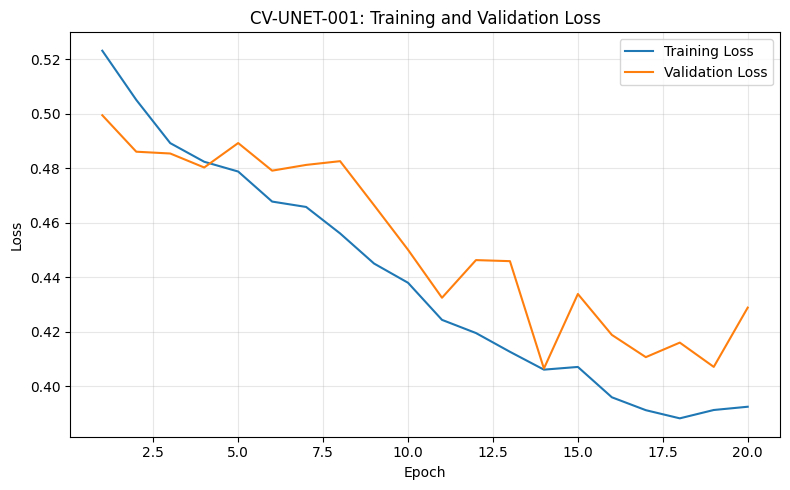

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path("/content/PetroVision/results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CV-UNET-001: Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_dir / "cv_unet_001_loss_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 9. Test Evaluation

After training, the best-performing CV-UNET-001 checkpoint is evaluated
on the previously unseen LADOS test set.

The test set contains 343 images and is kept separate from the training
and validation data.

For each test image, the trained U-Net produces a pixel-level prediction
of the target region. The predicted probabilities are converted into
binary segmentation masks using a threshold of 0.5.

The following metrics are calculated to evaluate segmentation performance:

- Intersection over Union (IoU)
- Dice Score
- Precision
- Recall
- Accuracy

Pixel-level True Positive (TP), False Positive (FP), False Negative (FN),
and True Negative (TN) counts are also calculated.

These measurements provide both overall segmentation metrics and detailed
information about the types of pixel-level errors made by the model.

The test set is used only for final evaluation and is not used to update
the model parameters.

In [ ]:
import torch
import numpy as np

# ---------------------------------------------------------
# Load best baseline checkpoint
# ---------------------------------------------------------

model = UNet(
    in_channels=3,
    out_channels=1
).to(DEVICE)

checkpoint = torch.load(
    "/content/PetroVision/models/unet_baseline_best.pt",
    map_location=DEVICE
)

# Existing checkpoint contains only model weights
model.load_state_dict(checkpoint)
model.eval()

print("Loaded CV-UNET-001 baseline checkpoint successfully.")


# ---------------------------------------------------------
# Test-set evaluation
# ---------------------------------------------------------

TP = 0
FP = 0
FN = 0
TN = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        logits = model(images)
        probabilities = torch.sigmoid(logits)

        predictions = (probabilities >= 0.5).float()

        TP += ((predictions == 1) & (masks == 1)).sum().item()
        FP += ((predictions == 1) & (masks == 0)).sum().item()
        FN += ((predictions == 0) & (masks == 1)).sum().item()
        TN += ((predictions == 0) & (masks == 0)).sum().item()


# ---------------------------------------------------------
# Metrics
# ---------------------------------------------------------

epsilon = 1e-8

iou = TP / (TP + FP + FN + epsilon)

dice = (2 * TP) / (
    2 * TP + FP + FN + epsilon
)

precision = TP / (
    TP + FP + epsilon
)

recall = TP / (
    TP + FN + epsilon
)

accuracy = (
    TP + TN
) / (
    TP + TN + FP + FN + epsilon
)


# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("PETROVISION — CV-UNET-001 BASELINE TEST RESULTS")
print("=" * 70)

print(f"Test samples : {len(test_dataset)}")

print("\nSegmentation Metrics")
print("-" * 40)

print(f"IoU          : {iou:.4f}")
print(f"Dice         : {dice:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Accuracy     : {accuracy:.4f}")

print("\nPixel Counts")
print("-" * 40)

print(f"TP : {TP:,}")
print(f"FP : {FP:,}")
print(f"FN : {FN:,}")
print(f"TN : {TN:,}")

print("=" * 70)

Loaded CV-UNET-001 baseline checkpoint successfully.

PETROVISION — CV-UNET-001 BASELINE TEST RESULTS
Test samples : 343

Segmentation Metrics
----------------------------------------
IoU          : 0.6638
Dice         : 0.7979
Precision    : 0.7648
Recall       : 0.8340
Accuracy     : 0.7751

Pixel Counts
----------------------------------------
TP : 9,981,715
FP : 3,068,945
FN : 1,987,188
TN : 7,441,000


## Test Performance Visualization

The quantitative segmentation metrics are visualized to provide a direct
overview of the baseline model's test-set performance.

The metrics describe different aspects of segmentation quality:

- IoU: overlap between predicted and ground-truth regions
- Dice: similarity between predicted and ground-truth regions
- Precision: proportion of predicted petroleum pixels that are correct
- Recall: proportion of ground-truth petroleum pixels detected
- Accuracy: proportion of correctly classified pixels

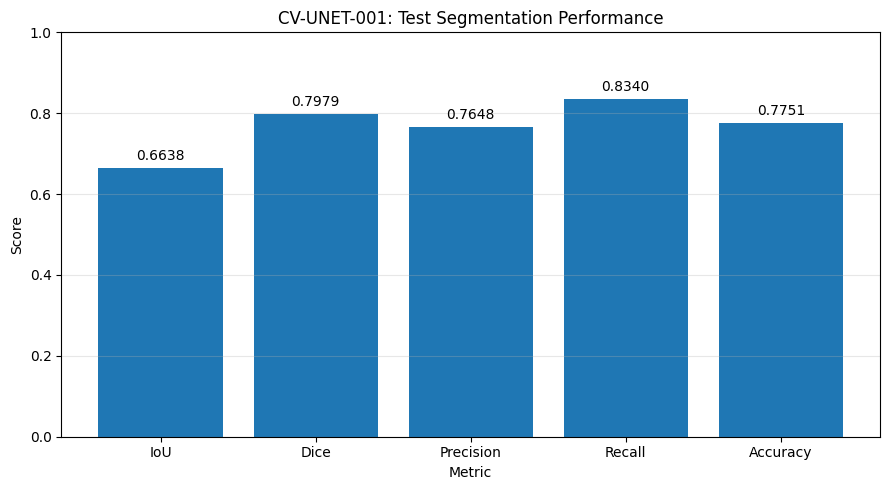

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

metrics = {
    "IoU": iou,
    "Dice": dice,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy
}

figures_dir = Path("/content/PetroVision/results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)

plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("CV-UNET-001: Test Segmentation Performance")

for bar, value in zip(bars, metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_dir / "cv_unet_001_test_metrics.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 10. Qualitative Analysis

Quantitative metrics describe the overall segmentation performance of the
model, but they do not show how the model behaves on individual images.

Therefore, representative samples from the unseen test set are visualized
to compare:

- the original RGB image
- the ground-truth segmentation mask
- the U-Net predicted mask
- an overlay of the prediction on the original image

This analysis helps identify:

- correctly detected target regions
- missed target regions
- false-positive regions
- boundary alignment
- over-segmentation and under-segmentation

The examples are selected from the test set and are not used for model
training.

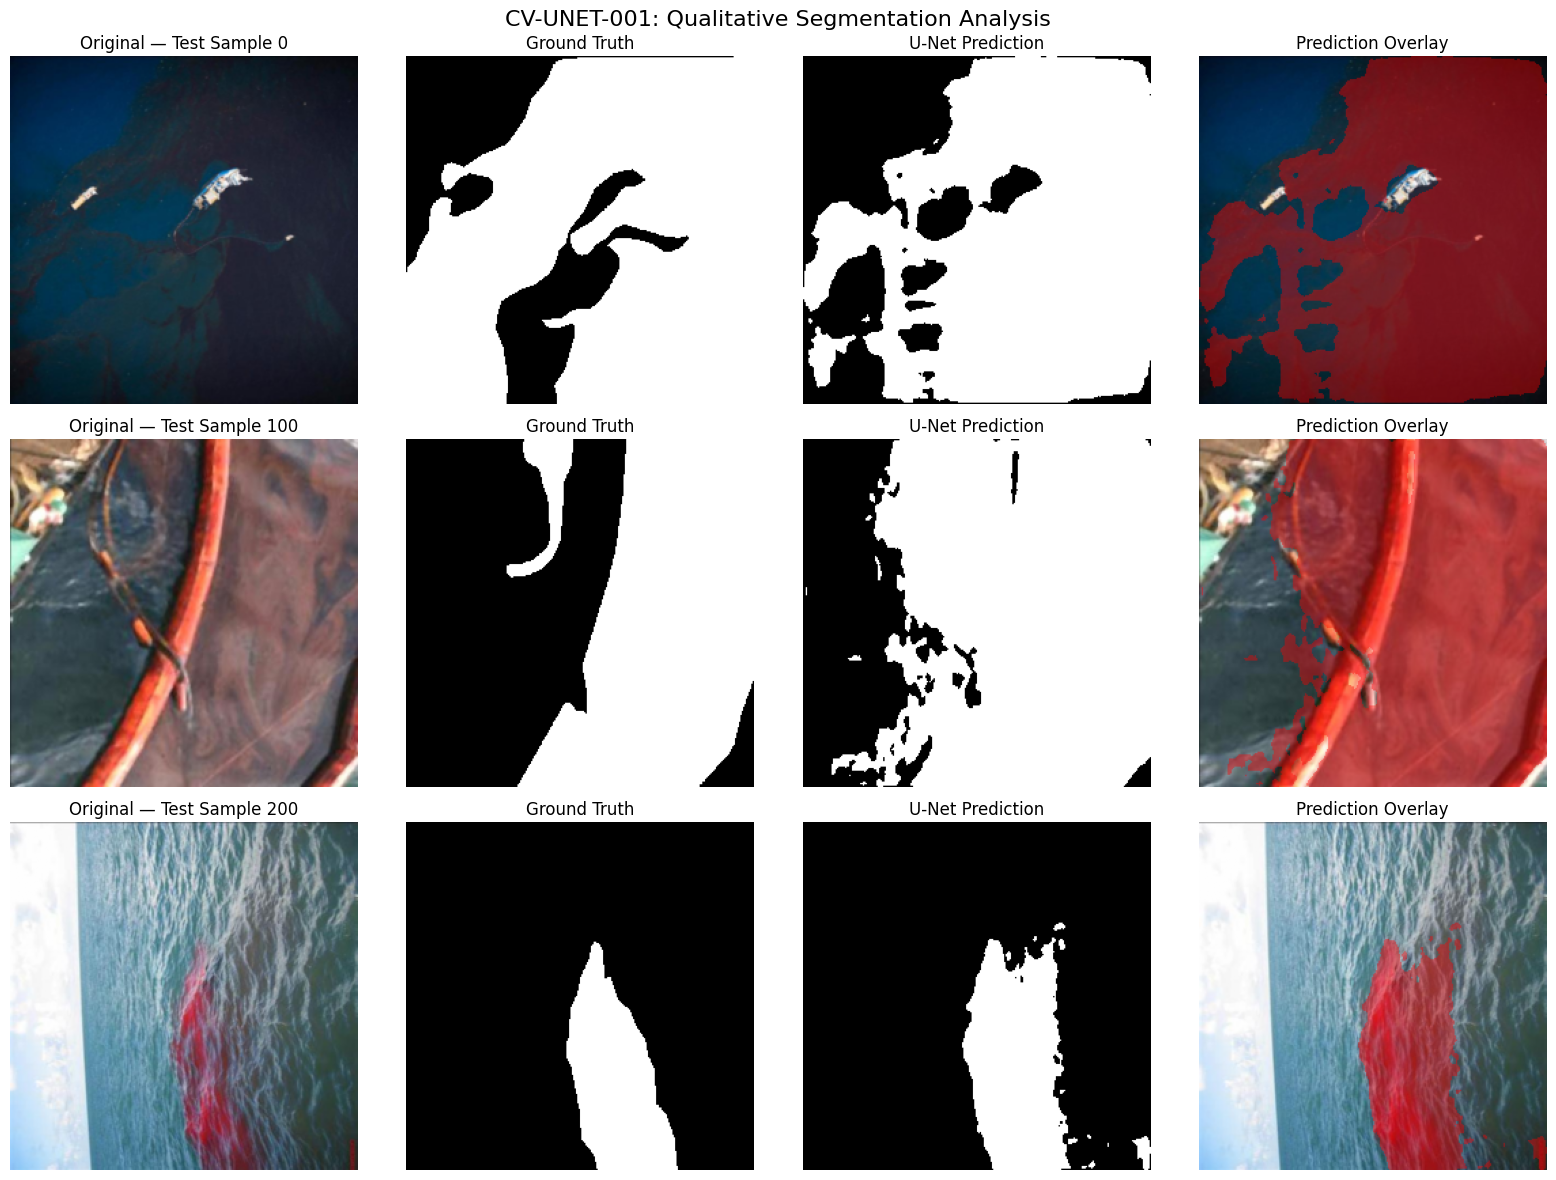

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path


# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

sample_indices = [0, 100, 200]

figures_dir = Path("/content/PetroVision/results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Helper function
# ---------------------------------------------------------

def predict_single_sample(dataset, index, model, device):
    """
    Generate a segmentation prediction for one test image.
    """

    image_tensor, mask_tensor = dataset[index]

    image_input = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_input)
        probabilities = torch.sigmoid(logits)

    prediction = (probabilities >= 0.5).float()

    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    ground_truth = mask_tensor.squeeze(0).cpu().numpy()
    prediction = prediction.squeeze().cpu().numpy()

    return image, ground_truth, prediction


# ---------------------------------------------------------
# Generate qualitative comparison
# ---------------------------------------------------------

model.eval()

fig, axes = plt.subplots(
    len(sample_indices),
    4,
    figsize=(16, 4 * len(sample_indices))
)

if len(sample_indices) == 1:
    axes = np.expand_dims(axes, axis=0)


for row, index in enumerate(sample_indices):

    image, ground_truth, prediction = predict_single_sample(
        test_dataset,
        index,
        model,
        DEVICE
    )

    # Prediction overlay
    overlay = image.copy()

    # Highlight predicted target region
    overlay[prediction == 1] = (
        0.6 * overlay[prediction == 1]
        + 0.4 * np.array([1.0, 0.0, 0.0])
    )

    # -----------------------------------------------------
    # Original
    # -----------------------------------------------------

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Original — Test Sample {index}")
    axes[row, 0].axis("off")

    # -----------------------------------------------------
    # Ground Truth
    # -----------------------------------------------------

    axes[row, 1].imshow(ground_truth, cmap="gray")
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    # -----------------------------------------------------
    # Prediction
    # -----------------------------------------------------

    axes[row, 2].imshow(prediction, cmap="gray")
    axes[row, 2].set_title("U-Net Prediction")
    axes[row, 2].axis("off")

    # -----------------------------------------------------
    # Overlay
    # -----------------------------------------------------

    axes[row, 3].imshow(overlay)
    axes[row, 3].set_title("Prediction Overlay")
    axes[row, 3].axis("off")


plt.suptitle(
    "CV-UNET-001: Qualitative Segmentation Analysis",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    figures_dir / "cv_unet_001_qualitative_analysis.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 11. Error Analysis

Pixel-level error analysis is used to understand how the segmentation model
makes correct and incorrect predictions.

Each pixel is categorized as:

- True Positive (TP): predicted target and ground truth target
- False Positive (FP): predicted target but ground truth non-target
- False Negative (FN): predicted non-target but ground truth target
- True Negative (TN): predicted non-target and ground truth non-target

The resulting pixel counts provide additional context for interpreting
precision, recall, IoU, and Dice.

This analysis is performed on the complete unseen test set.

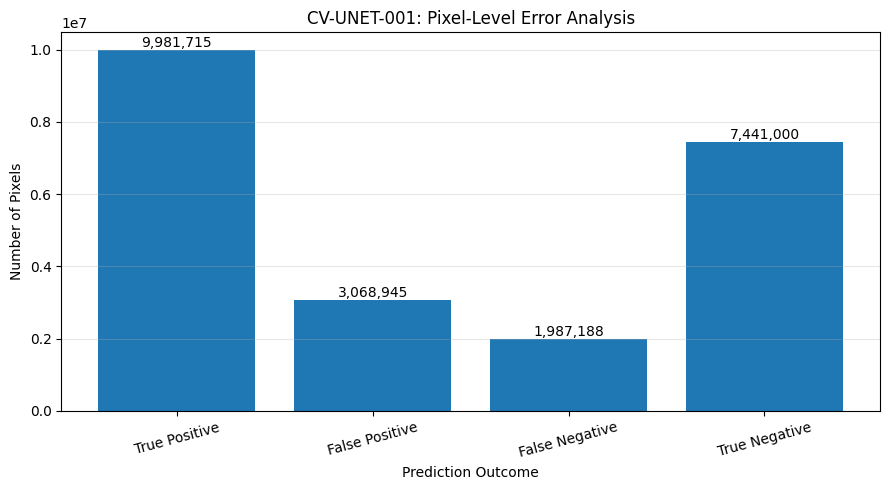

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path


# ---------------------------------------------------------
# Pixel outcome counts from test evaluation
# ---------------------------------------------------------

labels = [
    "True Positive",
    "False Positive",
    "False Negative",
    "True Negative"
]

values = [
    TP,
    FP,
    FN,
    TN
]


# ---------------------------------------------------------
# Create visualization
# ---------------------------------------------------------

figures_dir = Path("/content/PetroVision/results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    labels,
    values
)

plt.ylabel("Number of Pixels")
plt.xlabel("Prediction Outcome")
plt.title("CV-UNET-001: Pixel-Level Error Analysis")

plt.xticks(rotation=15)

# Display values above bars
for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    figures_dir / "cv_unet_001_pixel_error_analysis.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 12. Results and Interpretation

CV-UNET-001 was evaluated on 343 previously unseen test images.

The model achieved the following segmentation performance:

| Metric | Result |
|---|---:|
| IoU | 0.6638 |
| Dice | 0.7979 |
| Precision | 0.7648 |
| Recall | 0.8340 |
| Accuracy | 0.7751 |

The model detects a substantial portion of the annotated petroleum-related
regions, as indicated by the recall value. However, the lower precision
indicates that some predicted target pixels do not correspond to the
ground-truth target regions.

The qualitative visualizations provide additional evidence of how the model
segments target regions and where over-segmentation or missed regions occur.

These results establish CV-UNET-001 as the baseline for subsequent
computer-vision experiments in PetroVision.